
# 🚦 Traffic Sign Classification (GTSRB)
## Student CNN + Correct Training, Evaluation, Inference + CLIP Text Explanation

**Level:** Master’s / Postgraduate  
**Dataset:** GTSRB (Hugging Face)

This notebook:
- Trains a student CNN **correctly**
- Evaluates accuracy **correctly**
- Performs inference with **correct label decoding**
- Uses CLIP **only for textual explanation**, not scoring


## 1. Environment Setup

In [ ]:
!pip install -q torch torchvision datasets transformers gradio

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset
from transformers import CLIPModel, CLIPProcessor
import torch.nn.functional as F
import gradio as gr
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


/home/vijay2998/traffic-sign-classifier-cnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 2. Load GTSRB Dataset

In [2]:

ds = load_dataset("tanganke/gtsrb")

train_hf = ds["train"].shuffle(seed=42).select(range(10000))
test_hf  = ds["test"].shuffle(seed=42).select(range(1000))

len(train_hf), len(test_hf)


Generating spatter split: 100%|██████████| 12630/12630 [00:00<00:00, 53497.97 examples/s]


(10000, 1000)

## 3. Image Preprocessing (Student CNN)

In [3]:

student_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])


## 4. PyTorch Dataset Wrapper

In [4]:

class GTSRBDataset(Dataset):
    def __init__(self, hf_ds, transform):
        self.ds = hf_ds
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        image = self.transform(item["image"])
        label = int(item["label"])  # critical: keep label untouched
        return image, label


## 5. DataLoaders

In [5]:

train_loader = DataLoader(
    GTSRBDataset(train_hf, student_transform),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    GTSRBDataset(test_hf, student_transform),
    batch_size=32
)


## 6. Student CNN Model

In [6]:

class StudentCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = StudentCNN().to(device)
model


StudentCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=43, bias=True)
  )
)

## 7. Training Setup

In [7]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


## 8. Training Loop (Correct)

In [8]:

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


## 9. Evaluation Loop (Correct)

In [9]:

def evaluate_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


## 10. Train Student Model

In [10]:

num_epochs = 15

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader)
    test_acc = evaluate_accuracy(model, test_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Loss: {train_loss:.4f} | "
        f"Test Accuracy: {test_acc*100:.2f}%"
    )


Epoch [1/15] | Loss: 2.7737 | Test Accuracy: 43.30%
Epoch [2/15] | Loss: 1.5158 | Test Accuracy: 69.40%
Epoch [3/15] | Loss: 0.9780 | Test Accuracy: 79.20%
Epoch [4/15] | Loss: 0.7130 | Test Accuracy: 83.20%
Epoch [5/15] | Loss: 0.5620 | Test Accuracy: 87.30%
Epoch [6/15] | Loss: 0.4652 | Test Accuracy: 88.20%
Epoch [7/15] | Loss: 0.3992 | Test Accuracy: 87.60%
Epoch [8/15] | Loss: 0.3522 | Test Accuracy: 89.90%
Epoch [9/15] | Loss: 0.2940 | Test Accuracy: 91.00%
Epoch [10/15] | Loss: 0.2661 | Test Accuracy: 91.80%
Epoch [11/15] | Loss: 0.2551 | Test Accuracy: 92.40%
Epoch [12/15] | Loss: 0.2276 | Test Accuracy: 93.00%
Epoch [13/15] | Loss: 0.2111 | Test Accuracy: 92.30%
Epoch [14/15] | Loss: 0.2093 | Test Accuracy: 93.40%
Epoch [15/15] | Loss: 0.1744 | Test Accuracy: 92.30%


## 11. Human-Readable Label Mapping

In [11]:

GTSRB_LABELS = {
    0: "Speed limit 20 km/h", 1: "Speed limit 30 km/h",
    2: "Speed limit 50 km/h", 3: "Speed limit 60 km/h",
    4: "Speed limit 70 km/h", 5: "Speed limit 80 km/h",
    6: "End of speed limit 80 km/h", 7: "Speed limit 100 km/h",
    8: "Speed limit 120 km/h", 9: "No passing (cars)",
    10: "No passing (trucks)", 11: "Intersection warning",
    12: "Priority road", 13: "Yield", 14: "STOP",
    15: "No vehicles", 16: "No trucks", 17: "No entry",
    18: "General danger", 19: "Curve left",
    20: "Curve right", 21: "Double curve",
    22: "Bumpy road", 23: "Slippery road",
    24: "Road narrows", 25: "Road work",
    26: "Traffic signal ahead", 27: "Pedestrians",
    28: "Children crossing", 29: "Bicycles crossing",
    30: "Ice / snow", 31: "Wild animals",
    32: "End of all restrictions", 33: "Turn right mandatory",
    34: "Turn left mandatory", 35: "Go straight",
    36: "Go straight or right", 37: "Go straight or left",
    38: "Keep right", 39: "Keep left",
    40: "Roundabout", 41: "End of no passing (cars)",
    42: "End of no passing (trucks)"
}

def decode_gtsrb(idx):
    return GTSRB_LABELS[int(idx)]


## 12. Inference Example

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.84313726..1.0].


Predicted: Turn right mandatory
Actual  : Turn right mandatory


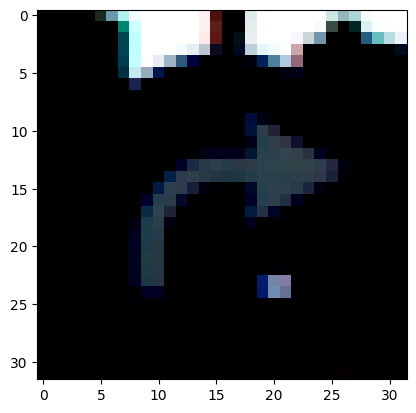

In [12]:

model.eval()
idx = 500
image, true_label = GTSRBDataset(test_hf, student_transform)[idx]

with torch.no_grad():
    pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()

print("Predicted:", decode_gtsrb(pred))
print("Actual  :", decode_gtsrb(true_label))

import matplotlib.pyplot as plt
from PIL import Image

plt.imshow(image.permute(1, 2, 0))
plt.show()


## 13. CLIP for Textual Explanation Only

In [13]:

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

clip_texts = list(GTSRB_LABELS.values())
text_inputs = clip_processor(text=clip_texts, return_tensors="pt", padding=True).to(device)

def clip_describe(image):
    inputs = clip_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        img_feat = clip_model.get_image_features(**inputs)
        txt_feat = clip_model.get_text_features(**text_inputs)
        logits = img_feat @ txt_feat.T
        idx = logits.argmax(dim=1).item()
    return clip_texts[idx]


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 577.68it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


## 14. Gradio App (Student Prediction + CLIP Explanation)

In [14]:
import random
import os

ds = load_dataset("tanganke/gtsrb")

os.makedirs("hf_test_images", exist_ok=True)

indices = random.sample(range(len(ds["test"])), 10)

for i, idx in enumerate(indices):
    sample = ds["test"][idx]
    image = sample["image"]
    label = sample["label"]

    image.save(f"hf_test_images/img_{i}_label_{label}.png")

print("Downloaded 10 images to hf_test_images/")


Downloaded 10 images to hf_test_images/


In [ ]:
def predict_gradio(image):
    # --- Student model inference ---
    model.eval()  # CRITICAL

    img_tensor = student_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img_tensor)
        probs = F.softmax(logits, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs.max(dim=1).values.item()

    student_label = decode_gtsrb(pred_idx)

    # --- CLIP textual explanation (explicit & safe) ---
    clip_text = clip_describe(image)

    return (
        f"Student model prediction:\n"
        f"• {student_label}\n"
        f"• Confidence: {confidence*100:.2f}%\n\n"
        f"CLIP description:\n"
        f"• {clip_text}"
    )
gr.Interface(
    fn=predict_gradio,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Traffic Sign Classifier (Student + CLIP Explanation)"
).launch(share=True)


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://e74f9f9fd975241109.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/home/vijay2998/traffic-sign-classifier-cnn/.venv/lib/python3.12/site-packages/gradio/queueing.py", line 766, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vijay2998/traffic-sign-classifier-cnn/.venv/lib/python3.12/site-packages/gradio/route_utils.py", line 355, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vijay2998/traffic-sign-classifier-cnn/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 2157, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vijay2998/traffic-sign-classifier-cnn/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 1634, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/